# TRANSFER FUNCTION EXTENSION

I want to use a numerical transfer function that spans from CMB to LISA scales! There are two papers where they dicuss enhanced TFs.
Shirai and Sawaika "Primordial gravitational waves, precisely: The role of thermodynamics in the Standard Model" (https://arxiv.org/abs/1803.01038 and data is available here: https://member.ipmu.jp/satoshi.shirai/EOS2018) AND Kite et al "Clarifying transfer function approximations for the large-scale gravitational wave background in ΛCDM" (https://arxiv.org/abs/2107.13351 and data is found here: https://zenodo.org/records/5141789). The first paper was published first and they provide data for smaller wavelength scales, whereas teh second provides data for large wavelength scales. I need it to move across both.

Both of these paper display a plot for $\Omega_{GW}$ across all scales but it is tricky because the data the first paper from Shirai provodes data that only starts at $k ~ 10^{-8}$ Hz or $10^7 Mpc^{-1}$.

I could even use an approximate form for the ranges smaller than this but ugh. It would be nice to use these papers, but I just need a TF to use that spans across my small k values (CMB scales) and onto large k-modes (PTA and LISA scales). So, I am going to try to use their functions, just try to get the TF by itself across the scales and see if I can have them connect and look the same way I expect them to in the paper.

In [1]:
import sys
import os
import glob
import re
import random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numdifftools as nd
import pygsl.rng
from matplotlib import cm
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib import colors as mcolors
from matplotlib.ticker import ScalarFormatter
from scipy.integrate import (
    solve_ivp,
    odeint,
    cumulative_trapezoid,
)
from scipy.interpolate import (
    UnivariateSpline,
    splrep,
    splev,
    CubicSpline,
    interp1d,
    PchipInterpolator,
    InterpolatedUnivariateSpline,
)
from matplotlib.lines import Line2D
import corner
from matplotlib.ticker import ScalarFormatter
import matplotlib.ticker as ticker



# --- Paths -----------------------------------------------------
# Where the InflationModels package lives, so we can import from it
INFLATION_MODELS_PATH = Path(
    "/Users/epmeador/Desktop/research/rwarthur/"
    "inflation_gravitywaves/inflation_code/InflationModels"
)
if str(INFLATION_MODELS_PATH) not in sys.path:
    sys.path.append(str(INFLATION_MODELS_PATH))

# Where the actual batch/model output directories live
BASE_PATH_ROOT = Path(
    "/Users/epmeador/Desktop/research/rwarthur/"
    "inflation_gravitywaves/inflation_code/"
    "Slow-Roll Parameters Tests/higgs_potential_tests"
)
base_path_root = BASE_PATH_ROOT


In [2]:
plt.rcParams.update({
    "text.usetex": False,
    "mathtext.fontset": "cm",
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "DejaVu Serif"],
    "axes.labelsize": 18,
    "axes.titlesize": 17,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "figure.titlesize": 22,
    "axes.linewidth": 1.3,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
})

## Plot TF Data from Shirai and Saikawa (Ideal for Large k/ Small wavelengths)

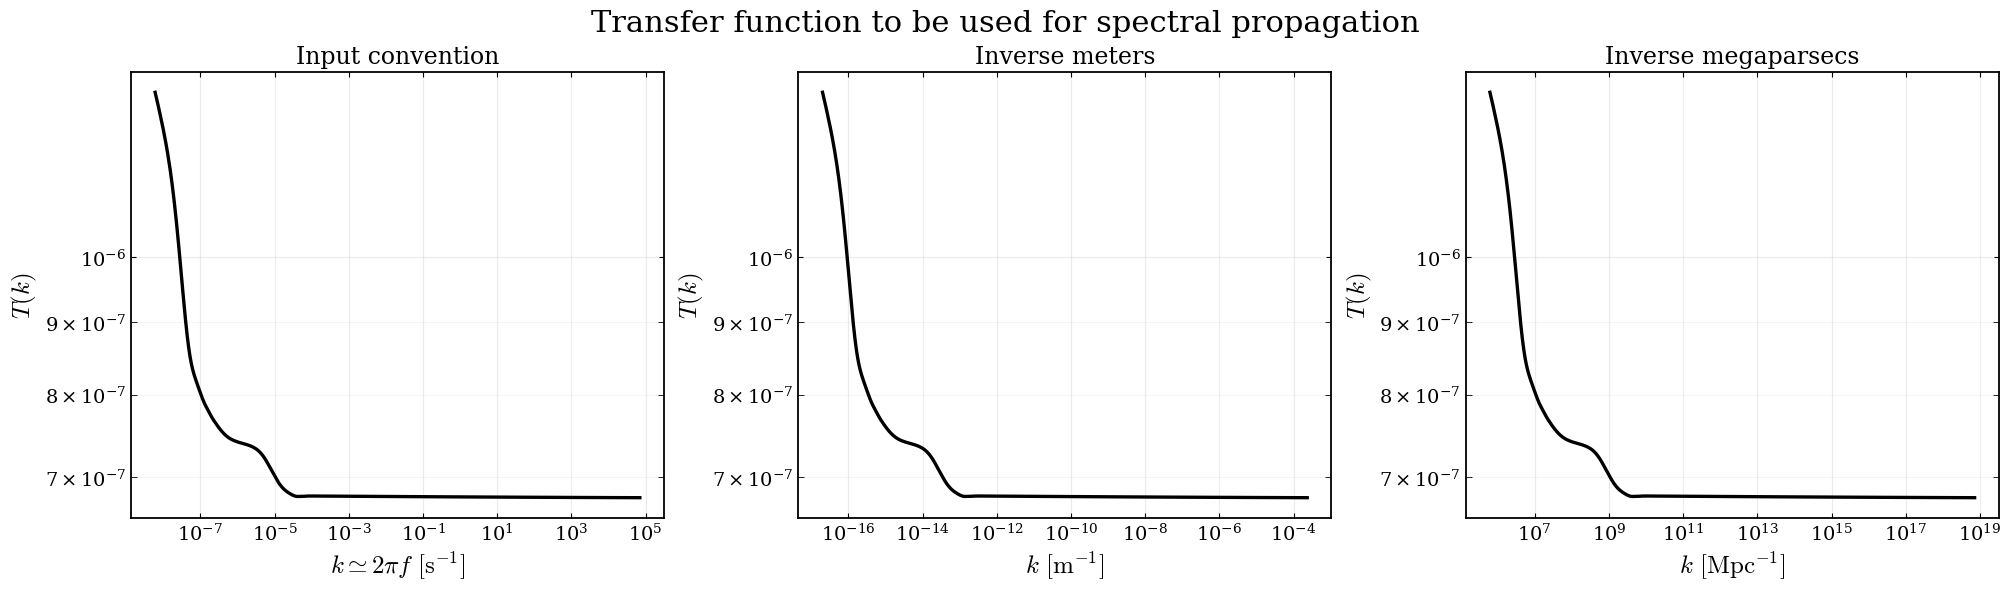

k from data for tf:
6e-09 69740.4

f from data for tf:
9.5493e-10 11099.5

TF median from data:
6.77425e-07 1.3063e-06

k after converting to inverse Mpc:
617562.9710460028 7.178159862110426e+18

ratio of k/(2*pi*f):
0.9999927220232102 1.0000068685629133


In [2]:


base_path_tf = Path(
    "/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/"
    "inflation_code/Slow-Roll Parameters Tests"
)

tf_k = np.loadtxt(base_path_tf / "k_file_tf.dat")
tf_f = np.loadtxt(base_path_tf / "f_file_tf.dat")
tf_median = np.loadtxt(base_path_tf / "Tf_median.dat")

tf_k_invm = tf_f * 2.0 * np.pi / 299792458.0
tf_k_invMpc = tf_k_invm * 3.085677581e22

fig, axes = plt.subplots(
    1,
    3,
    figsize=(20, 5.8),
    constrained_layout=True,
)

plot_data = [
    (
        tf_k,
        tf_median,
        r"$k \simeq 2\pi f\ [{\rm s}^{-1}]$",
        r"$T(k)$",
        r"Input convention",
    ),
    (
        tf_k_invm,
        tf_median,
        r"$k\ [{\rm m}^{-1}]$",
        r"$T(k)$",
        r"Inverse meters",
    ),
    (
        tf_k_invMpc,
        tf_median,
        r"$k\ [{\rm Mpc}^{-1}]$",
        r"$T(k)$",
        r"Inverse megaparsecs",
    ),
]

for ax, (x, y, xlabel, ylabel, title) in zip(axes, plot_data):
    ax.loglog(
        x,
        y,
        color="black",
        lw=2.4,
    )

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    ax.grid(True, which="major", alpha=0.25)
    ax.grid(True, which="minor", alpha=0.12)
    ax.minorticks_on()
    ax.tick_params(axis="y", which="minor", length=4)

fig.suptitle(r"Transfer function to be used for spectral propagation", fontsize=22)

plt.savefig(
    "transfer_function_conventions.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("k from data for tf:")
print(tf_k.min(), tf_k.max())

print("\nf from data for tf:")
print(tf_f.min(), tf_f.max())

print("\nTF median from data:")
print(tf_median.min(), tf_median.max())

print("\nk after converting to inverse Mpc:")
print(tf_k_invMpc.min(), tf_k_invMpc.max())

ratio = tf_k / (2.0 * np.pi * tf_f)

print("\nratio of k/(2*pi*f):")
print(np.nanmin(ratio), np.nanmax(ratio))




## Plot TF Data from Kite (Ideal for Small k/ Large wavelengths)


In [4]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

base_path_kite = Path(
    "/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/InflationModels/data_availability"
)

# ---------------------------------------------------------
# Helper functions
# ---------------------------------------------------------

def get_header_lines(filename):
    """Return initial comment/header lines from a .dat file."""
    headers = []

    with open(filename, "r") as f:
        for line in f:
            stripped = line.strip()

            if (
                stripped.startswith("#")
                or stripped.startswith("%")
                or stripped.startswith("//")
            ):
                headers.append(stripped)
            else:
                break

    return headers


def load_dat(filename):
    """Load numerical data, ignoring commented header lines."""
    return np.genfromtxt(
        filename,
        comments="#",
        invalid_raise=False,
    )


# ---------------------------------------------------------
# Find everything
# ---------------------------------------------------------

files = sorted(base_path_kite.rglob("*.dat"))

print(f"Found {len(files)} .dat files\n")
print("=" * 100)

for filename in files:

    rel = filename.relative_to(base_path_kite)

    print(f"\nFILE: {rel}")
    print("-" * 100)

    headers = get_header_lines(filename)

    if headers:
        print("HEADER:")
        for h in headers:
            print("   ", h)
    else:
        print("No commented header found.")

    try:
        data = load_dat(filename)

        print("\nShape:", data.shape)

        if data.ndim == 1:
            data = data[:, None]

        for j in range(data.shape[1]):

            col = data[:, j]
            finite = col[np.isfinite(col)]

            if len(finite) == 0:
                continue

            print(
                f"column {j:2d}: "
                f"min = {finite.min():.6e}, "
                f"max = {finite.max():.6e}"
            )

    except Exception as err:
        print("Could not load:", err)

    print("=" * 100)

Found 23 .dat files


FILE: GW.fnu0.dat
----------------------------------------------------------------------------------------------------
HEADER:
    # f_{\nu,0} \mathcal{D}

Shape: (2048, 2)
column  0: min = 0.000000e+00, max = 1.000000e+00
column  1: min = 3.514370e-01, max = 1.000000e+00

FILE: GW.gstar_full.dat
----------------------------------------------------------------------------------------------------
HEADER:
    # k\,[\rm\,Mpc^{-1}] {g_*{\rm\,on,\,\,free}} {g_*{\rm\,on,\,\,Damped}} {g_*{\rm\,off,\,\,free}} {g_*{\rm\,off,\,\,Damped}}

Shape: (512, 5)
column  0: min = 3.000000e+00, max = 1.000000e+12
column  1: min = 7.534560e-03, max = 9.998534e-03
column  2: min = 7.133450e-03, max = 9.998534e-03
column  3: min = 9.437972e-03, max = 1.602452e-02
column  4: min = 7.570794e-03, max = 1.602452e-02

FILE: GW.sing_0.001.dat
----------------------------------------------------------------------------------------------------
HEADER:
    # \eta\,[\rm\,Mpc] a H h_{\rm\,free} h'


Shape: (500000, 5)
column  0: min = 1.000000e-04, max = 3.000000e+00
column  1: min = -8.687305e-02, max = 7.715102e-01
column  2: min = -5.834021e-05, max = 2.680193e-05
column  3: min = -8.697588e-02, max = 7.716588e-01
column  4: min = -5.838081e-05, max = 2.685594e-05

FILE: large_k_spectra/GW.GW_today_nolam_env.dat
----------------------------------------------------------------------------------------------------
HEADER:
    # k\,[\rm\,Mpc^{-1}] h^{\rm\,envelope}_{\rm\,free} h'^{\rm\,envelope}_{\rm\,free} h^{\rm\,envelope}_{\rm\,damp} h'^{\rm\,envelope}_{\rm\,damp}

Shape: (128, 5)
column  0: min = 1.000000e-02, max = 3.000000e+00
column  1: min = 7.178056e-07, max = 2.889749e-04
column  2: min = 2.150917e-06, max = 2.889864e-06
column  3: min = 5.761758e-07, max = 2.705185e-04
column  4: min = 1.726890e-06, max = 2.705293e-06

FILE: large_k_spectra/GW.GW_today_noneff.dat
----------------------------------------------------------------------------------------------------
HEADER:

Try plotting:

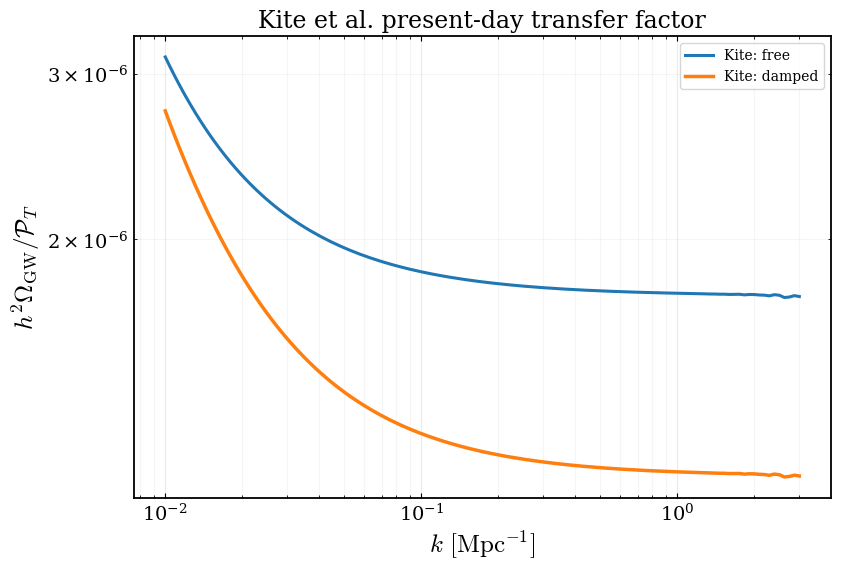

In [9]:
env_file = (
    base_path_kite
    / "large_k_spectra"
    / "GW.GW_today_standard_env.dat"
)

data = np.loadtxt(env_file)

k = data[:, 0]

T_env_free = data[:, 1]
Tp_env_free = data[:, 2]

T_env_damped = data[:, 3]
Tp_env_damped = data[:, 4]


# ---------------------------------------------------------
# Cosmology used by Kite
# ---------------------------------------------------------

h = 0.675

# H0 = 100 h km/s/Mpc
#
# Because T' is derivative wrt conformal time eta,
# and eta is in Mpc, H0 must also be in Mpc^{-1}.
#
# Divide km/s/Mpc by c [km/s].
# ---------------------------------------------------------

c_km_s = 299792.458

H0_Mpc_inv = 100.0 * h / c_km_s


# ---------------------------------------------------------
# Energy-density transfer factor
#
# Omega_GW / P_T
#
# Envelope squared has oscillation average 1/2.
# ---------------------------------------------------------

TF_free = (
    Tp_env_free**2
    / (24.0 * H0_Mpc_inv**2)
)

TF_damped = (
    Tp_env_damped**2
    / (24.0 * H0_Mpc_inv**2)
)


# ---------------------------------------------------------
# h^2 Omega_GW / P_T
#
# This is the convention that will be most convenient
# for comparison against Saikawa-Shirai.
# ---------------------------------------------------------

TFh2_free = h**2 * TF_free
TFh2_damped = h**2 * TF_damped


# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 6))

ax.loglog(
    k,
    TFh2_free,
    lw=2.2,
    label="Kite: free",
)

ax.loglog(
    k,
    TFh2_damped,
    lw=2.5,
    label="Kite: damped",
)

ax.set_xlabel(
    r"$k\ [{\rm Mpc}^{-1}]$"
)

ax.set_ylabel(
    r"$h^2\Omega_{\rm GW}/\mathcal{P}_T$"
)

ax.set_title(
    r"Kite et al. present-day transfer factor"
)

ax.grid(True, which="major", alpha=0.25)
ax.grid(True, which="minor", alpha=0.12)

ax.legend()

plt.show()

In [10]:
standard_env = np.loadtxt(
    base_path_kite
    / "large_k_spectra"
    / "GW.GW_today_standard_env.dat"
)

gstar = np.loadtxt(
    base_path_kite
    / "GW.gstar_full.dat"
)


print("\nSTANDARD ENVELOPE -- last row")
print("--------------------------------")
print("k             =", standard_env[-1, 0])
print("h free env    =", standard_env[-1, 1])
print("h' free env   =", standard_env[-1, 2])
print("h damp env    =", standard_env[-1, 3])
print("h' damp env   =", standard_env[-1, 4])


print("\nGSTAR FULL -- first row")
print("--------------------------------")
print("k                 =", gstar[0, 0])
print("g* on, free       =", gstar[0, 1])
print("g* on, damped     =", gstar[0, 2])
print("g* off, free      =", gstar[0, 3])
print("g* off, damped    =", gstar[0, 4])


STANDARD ENVELOPE -- last row
--------------------------------
k             = 2.999999999999968
h free env    = 7.182034783868687e-07
h' free env   = 2.155123272255618e-06
h damp env    = 5.76578261782393e-07
h' damp env   = 1.730159006065523e-06

GSTAR FULL -- first row
--------------------------------
k                 = 3.0
g* on, free       = 0.009437969497947256
g* on, damped     = 0.007570794370915766
g* off, free      = 0.009437972114429446
g* off, damped    = 0.007570794262521859


In [11]:
print("\nBoundary ratios:")
print(
    "gstar free / gstar-off free =",
    gstar[0, 1] / gstar[0, 3]
)

print(
    "damped/free with gstar on =",
    gstar[0, 2] / gstar[0, 1]
)

print(
    "damped/free with gstar off =",
    gstar[0, 4] / gstar[0, 3]
)


Boundary ratios:
gstar free / gstar-off free = 0.9999997227707225
damped/free with gstar on = 0.8021634709205622
damped/free with gstar off = 0.80216323705249


In [14]:
k_boundary = standard_env[-1, 0]

h_free_env  = standard_env[-1, 1]
hp_free_env = standard_env[-1, 2]

h_damp_env  = standard_env[-1, 3]
hp_damp_env = standard_env[-1, 4]

g_free  = gstar[0, 3]   # g* off, free
g_damp  = gstar[0, 4]   # g* off, damped


print("g_free / h_free_env:")
print(g_free / h_free_env)

print("\ng_free / hp_free_env:")
print(g_free / hp_free_env)

print("\ng_damp / h_damp_env:")
print(g_damp / h_damp_env)

print("\ng_damp / hp_damp_env:")
print(g_damp / hp_damp_env)

g_free / h_free_env:
13141.08382714567

g_free / hp_free_env:
4379.318916894891

g_damp / h_damp_env:
13130.557921344527

g_damp / hp_damp_env:
4375.779472279985


GW.gstar_full is not normalized the same as the enveloples. I think we need to multiply and use squared ratios like in the READ ME

Try plotting correction:

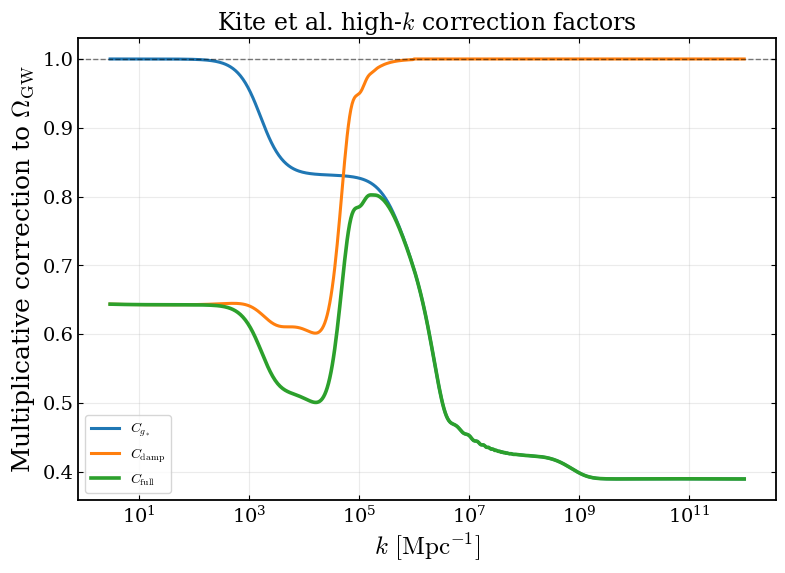

At k = 3 Mpc^-1:
C_gstar = 0.9999994455415218
C_damp  = 0.6434662340793236
C_full  = 0.6434658773040146

At largest k:
k       = 1000000000000.051
C_gstar = 0.3892379582312004
C_damp  = 1.0
C_full  = 0.3892379582312004


In [15]:
k_gstar = gstar[:, 0]

# g* correction alone
C_gstar = (
    gstar[:, 1] / gstar[:, 3]
)**2

# damping correction, with g* included
C_damp = (
    gstar[:, 2] / gstar[:, 1]
)**2

# total correction relative to the
# g*-off, undamped baseline
C_full = (
    gstar[:, 2] / gstar[:, 3]
)**2


fig, ax = plt.subplots(figsize=(9, 6))

ax.semilogx(
    k_gstar,
    C_gstar,
    lw=2.2,
    label=r"$C_{g_*}$",
)

ax.semilogx(
    k_gstar,
    C_damp,
    lw=2.2,
    label=r"$C_{\rm damp}$",
)

ax.semilogx(
    k_gstar,
    C_full,
    lw=2.6,
    label=r"$C_{\rm full}$",
)

ax.axhline(
    1.0,
    color="black",
    ls="--",
    lw=1.0,
    alpha=0.5,
)

ax.set_xlabel(r"$k\ [{\rm Mpc}^{-1}]$")
ax.set_ylabel(r"Multiplicative correction to $\Omega_{\rm GW}$")

ax.set_title(
    r"Kite et al. high-$k$ correction factors"
)

ax.grid(True, which="major", alpha=0.25)
ax.grid(True, which="minor", alpha=0.12)

ax.legend()

plt.show()


print("At k = 3 Mpc^-1:")
print("C_gstar =", C_gstar[0])
print("C_damp  =", C_damp[0])
print("C_full  =", C_full[0])

print("\nAt largest k:")
print("k       =", k_gstar[-1])
print("C_gstar =", C_gstar[-1])
print("C_damp  =", C_damp[-1])
print("C_full  =", C_full[-1])

WE have to make sure at 3, e get 0.643. They must meet.

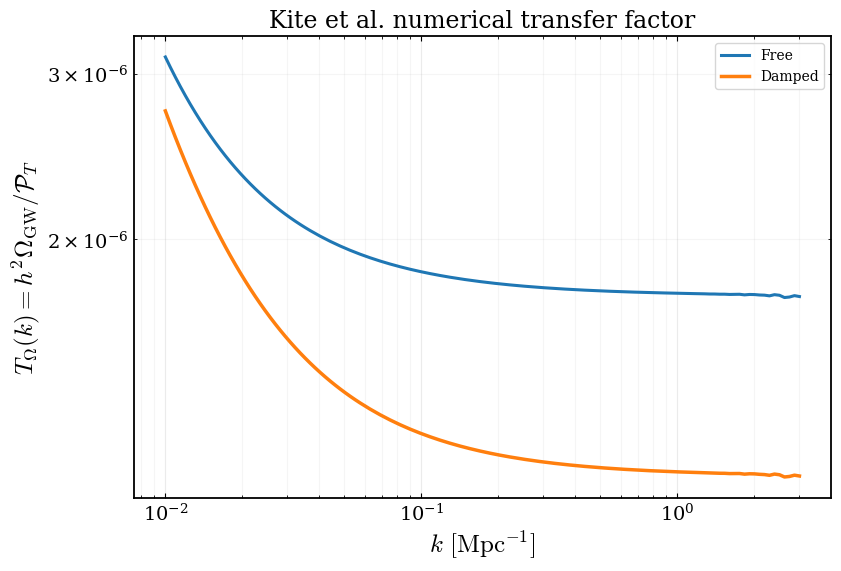

First point:
k = 0.01
Tomega free   = 3.1263262958958795e-06
Tomega damped = 2.739732522543849e-06

Last point:
k = 2.999999999999968
Tomega free   = 1.7392996017885516e-06
Tomega damped = 1.1209911905002203e-06

Damping ratio at k = 3:
0.6445072426553113


In [16]:
# ---------------------------------------------------------
# Kite numerical envelope
# ---------------------------------------------------------

standard_env = np.loadtxt(
    base_path_kite
    / "large_k_spectra"
    / "GW.GW_today_standard_env.dat"
)

k_env = standard_env[:, 0]

hp_free_env = standard_env[:, 2]
hp_damp_env = standard_env[:, 4]


# ---------------------------------------------------------
# Hubble constant in Mpc^{-1}
# ---------------------------------------------------------

h = 0.675
c_km_s = 299792.458

H0_Mpc_inv = 100.0 * h / c_km_s


# ---------------------------------------------------------
# Energy-density transfer factor
#
# T_Omega(k) = h^2 Omega_GW / P_T
#
# 1/2 comes from averaging the squared oscillatory envelope.
# ---------------------------------------------------------

Tomega_free = (
    h**2
    * hp_free_env**2
    / (24.0 * H0_Mpc_inv**2)
)

Tomega_damp = (
    h**2
    * hp_damp_env**2
    / (24.0 * H0_Mpc_inv**2)
)


# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 6))

ax.loglog(
    k_env,
    Tomega_free,
    lw=2.2,
    label="Free",
)

ax.loglog(
    k_env,
    Tomega_damp,
    lw=2.5,
    label="Damped",
)

ax.set_xlabel(r"$k\ [{\rm Mpc}^{-1}]$")

ax.set_ylabel(
    r"$T_\Omega(k)"
    r"=h^2\Omega_{\rm GW}/\mathcal{P}_T$"
)

ax.set_title(
    r"Kite et al. numerical transfer factor"
)

ax.grid(True, which="major", alpha=0.25)
ax.grid(True, which="minor", alpha=0.12)

ax.legend()

plt.show()


# ---------------------------------------------------------
# Diagnostics
# ---------------------------------------------------------

print("First point:")
print("k =", k_env[0])
print("Tomega free   =", Tomega_free[0])
print("Tomega damped =", Tomega_damp[0])

print("\nLast point:")
print("k =", k_env[-1])
print("Tomega free   =", Tomega_free[-1])
print("Tomega damped =", Tomega_damp[-1])

print("\nDamping ratio at k = 3:")
print(
    Tomega_damp[-1] / Tomega_free[-1]
)

Extend:

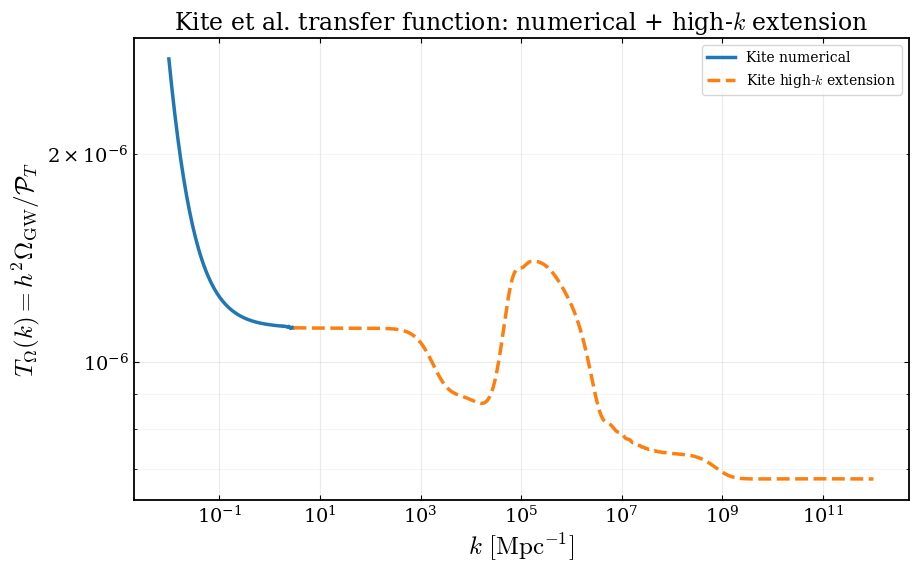

Boundary check:
numerical = 1.1209911905002203e-06
extended  = 1.1209911905002203e-06

High-k endpoint:
k = 1000000000000.051
Tomega = 6.780970640022251e-07


In [17]:
# High-k correction from GW.gstar_full.dat
k_high = gstar[:, 0]

C_full = (
    gstar[:, 2] / gstar[:, 3]
)**2

# Normalize the correction to unity at k = 3 Mpc^-1
C_full_normalized = C_full / C_full[0]

# Extend the numerical damped transfer factor
Tomega_high = Tomega_damp[-1] * C_full_normalized


# Combine numerical envelope + high-k extension
k_kite_full = np.concatenate([
    k_env,
    k_high[1:]
])

Tomega_kite_full = np.concatenate([
    Tomega_damp,
    Tomega_high[1:]
])


# Plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.loglog(
    k_env,
    Tomega_damp,
    lw=2.5,
    label="Kite numerical",
)

ax.loglog(
    k_high,
    Tomega_high,
    lw=2.5,
    ls="--",
    label=r"Kite high-$k$ extension",
)

ax.set_xlabel(r"$k\ [{\rm Mpc}^{-1}]$")
ax.set_ylabel(
    r"$T_\Omega(k)=h^2\Omega_{\rm GW}/\mathcal{P}_T$"
)

ax.set_title(
    r"Kite et al. transfer function: numerical + high-$k$ extension"
)

ax.grid(True, which="major", alpha=0.25)
ax.grid(True, which="minor", alpha=0.12)

ax.legend()

plt.show()


print("Boundary check:")
print("numerical =", Tomega_damp[-1])
print("extended  =", Tomega_high[0])

print("\nHigh-k endpoint:")
print("k =", k_high[-1])
print("Tomega =", Tomega_high[-1])

okay so lets rebuild kite paper convention without h^2

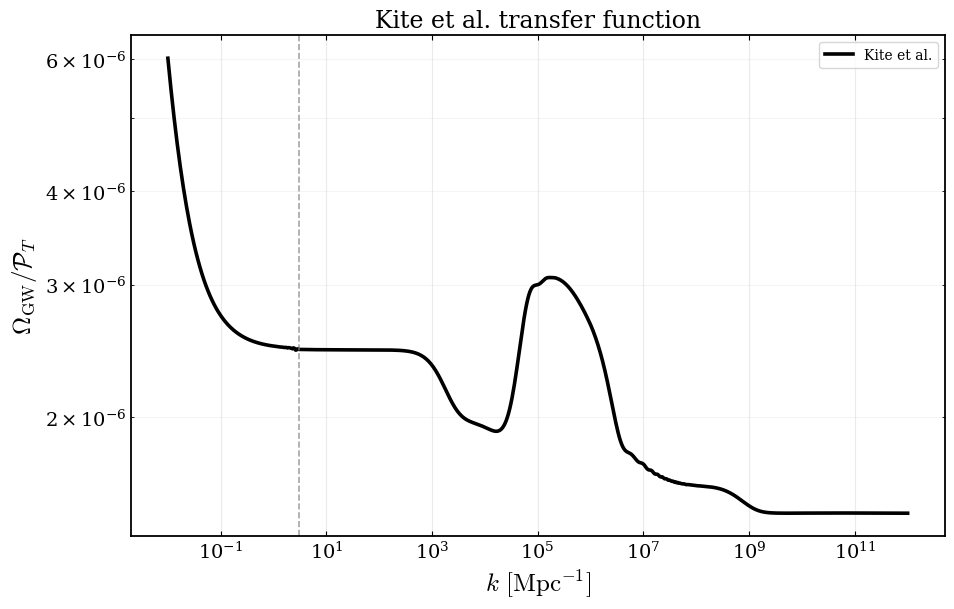

At k = 0.01 Mpc^-1:
6.013130364979641e-06

At k = 3 Mpc^-1:
2.460337317970305e-06

At k = 1e12 Mpc^-1:
1.4882788784685325e-06


In [18]:
# ============================================================
# FULL KITE TRANSFER FUNCTION
# Paper convention: Omega_GW / P_T
# No h^2 factor
# ============================================================

# ------------------------------------------------------------
# 1. Numerical Kite envelope: 1e-2 < k < 3 Mpc^-1
# ------------------------------------------------------------

standard_env = np.loadtxt(
    base_path_kite
    / "large_k_spectra"
    / "GW.GW_today_standard_env.dat"
)

k_env = standard_env[:, 0]

hp_free_env = standard_env[:, 2]
hp_damp_env = standard_env[:, 4]


# H0 in Mpc^-1
h = 0.675
c_km_s = 299792.458

H0_Mpc_inv = 100.0 * h / c_km_s


# ------------------------------------------------------------
# Omega_GW / P_T
#
# factor 1/24 because the envelope amplitude squared
# has oscillation average <cos^2> = 1/2
# ------------------------------------------------------------

Tomega_free = (
    hp_free_env**2
    / (24.0 * H0_Mpc_inv**2)
)

Tomega_damp = (
    hp_damp_env**2
    / (24.0 * H0_Mpc_inv**2)
)


# ------------------------------------------------------------
# 2. High-k Kite correction: 3 < k < 1e12 Mpc^-1
# ------------------------------------------------------------

gstar = np.loadtxt(
    base_path_kite / "GW.gstar_full.dat"
)

k_high = gstar[:, 0]

# Full physical correction:
# g* evolution + free-streaming damping
C_full = (
    gstar[:, 2] / gstar[:, 3]
)**2


# Normalize correction at k = 3 so it joins continuously
C_full_norm = C_full / C_full[0]


# High-k continuation of the damped numerical spectrum
Tomega_high = (
    Tomega_damp[-1]
    * C_full_norm
)


# ------------------------------------------------------------
# 3. Combine
# ------------------------------------------------------------

k_kite_full = np.concatenate([
    k_env,
    k_high[1:]
])

Tomega_kite_full = np.concatenate([
    Tomega_damp,
    Tomega_high[1:]
])


# ------------------------------------------------------------
# 4. Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10.5, 6.5)
)

# Full continuous curve
ax.loglog(
    k_kite_full,
    Tomega_kite_full,
    color="black",
    lw=2.6,
    label=r"Kite et al."
)

# Show the numerical/high-k division
ax.axvline(
    3.0,
    color="gray",
    ls="--",
    lw=1.2,
    alpha=0.7,
)

ax.set_xlabel(
    r"$k\ [{\rm Mpc}^{-1}]$"
)

ax.set_ylabel(
    r"$\Omega_{\rm GW}/\mathcal{P}_T$"
)

ax.set_title(
    r"Kite et al. transfer function"
)

ax.grid(
    True,
    which="major",
    alpha=0.25
)

ax.grid(
    True,
    which="minor",
    alpha=0.12
)

ax.legend()

plt.show()


# ------------------------------------------------------------
# Diagnostics
# ------------------------------------------------------------

print("At k = 0.01 Mpc^-1:")
print(Tomega_kite_full[0])

print("\nAt k = 3 Mpc^-1:")
print(Tomega_damp[-1])

print("\nAt k = 1e12 Mpc^-1:")
print(Tomega_high[-1])

overlay both TF

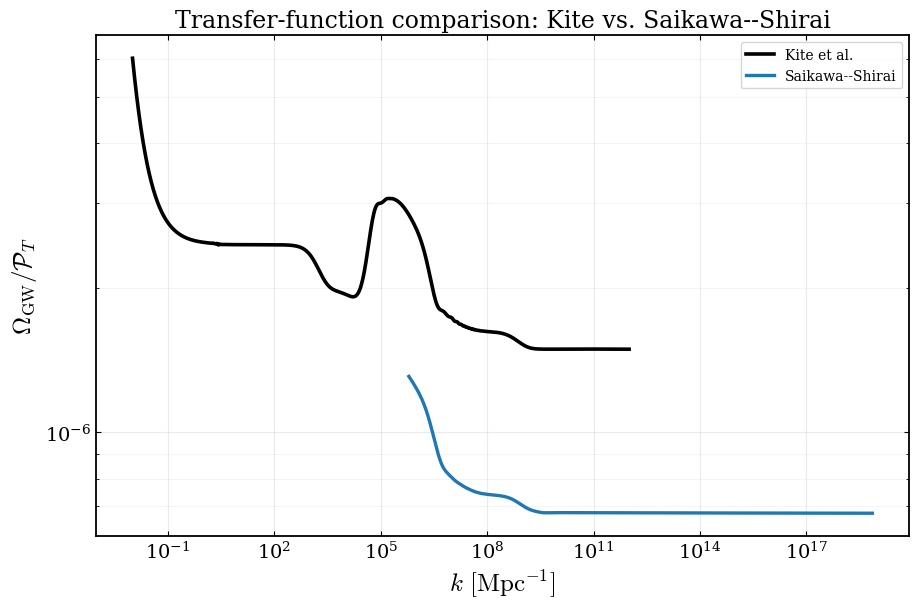

In [22]:
# ============================================================
# Compare Kite vs Saikawa-Shirai
# Same convention: Omega_GW / P_T
# ============================================================

fig, ax = plt.subplots(figsize=(10.5, 6.5))

# Kite full transfer function
ax.loglog(
    k_kite_full,
    Tomega_kite_full,
    color="black",
    lw=2.6,
    label=r"Kite et al."
)

# Saikawa-Shirai data
ax.loglog(
    tf_k_invMpc,
    tf_median,
    lw=2.4,
    label=r"Saikawa--Shirai"
)

ax.set_xlabel(r"$k\ [{\rm Mpc}^{-1}]$")
ax.set_ylabel(r"$\Omega_{\rm GW}/\mathcal{P}_T$")

ax.set_title(
    r"Transfer-function comparison: Kite vs. Saikawa--Shirai"
)

ax.grid(True, which="major", alpha=0.25)
ax.grid(True, which="minor", alpha=0.12)

ax.legend()

plt.show()

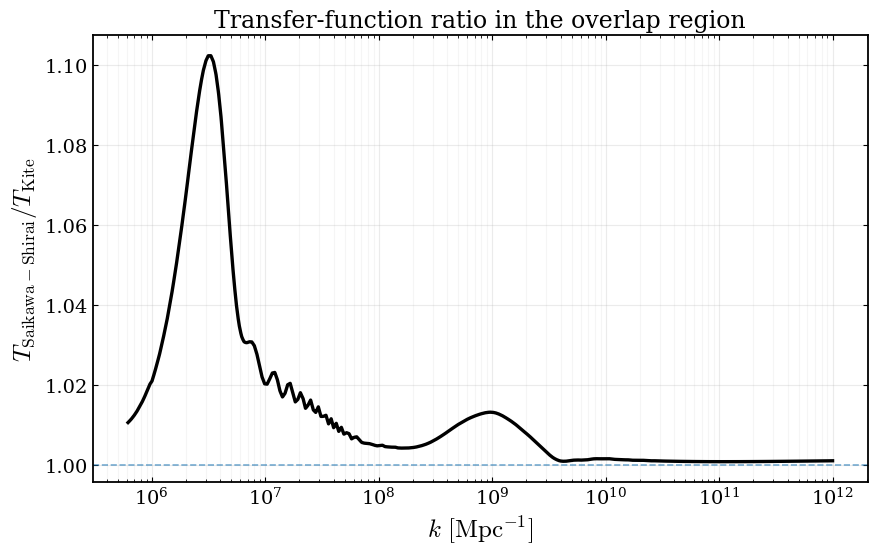

Ratio statistics:
min    = 1.0007749844460871
max    = 1.102229590808773
median = 1.0064518312143398
mean   = 1.0149991217253145
Maximum ratio:
k = 3308879.802810104 Mpc^-1
ratio = 1.102229590808773

Minimum ratio:
k = 111483137783.67545 Mpc^-1
ratio = 1.0007749844460871

Corresponding values at max:
Shirai = 2.101809602194787e-06
Kite   = 1.906870963836637e-06


In [24]:
# ---------------------------------------------------------
# Put Shirai in the same convention as Kite:
#
# Kite:
#     Omega_GW / P_T
#
# Shirai table:
#     h^2 Omega_GW / P_T
# ---------------------------------------------------------

h_compare = 0.675

T_shirai_noh2 = tf_median / h_compare**2


# ---------------------------------------------------------
# Interpolate Kite onto Shirai k values
# only within their overlapping k range
# ---------------------------------------------------------

from scipy.interpolate import interp1d

mask_overlap = (
    (tf_k_invMpc >= k_kite_full.min())
    & (tf_k_invMpc <= k_kite_full.max())
)

k_overlap = tf_k_invMpc[mask_overlap]
T_shirai_overlap = T_shirai_noh2[mask_overlap]


# log-log interpolation is safer here
kite_interp = interp1d(
    np.log(k_kite_full),
    np.log(Tomega_kite_full),
    kind="linear",
    bounds_error=True,
)

T_kite_overlap = np.exp(
    kite_interp(np.log(k_overlap))
)


# ---------------------------------------------------------
# Ratio
# ---------------------------------------------------------

ratio_SS_Kite = (
    T_shirai_overlap
    / T_kite_overlap
)


fig, ax = plt.subplots(figsize=(10, 5.8))

ax.semilogx(
    k_overlap,
    ratio_SS_Kite,
    color="black",
    lw=2.4,
)

ax.axhline(
    1.0,
    ls="--",
    lw=1.2,
    alpha=0.6,
)

ax.set_xlabel(
    r"$k\ [{\rm Mpc}^{-1}]$"
)

ax.set_ylabel(
    r"$T_{\rm Saikawa-Shirai}/T_{\rm Kite}$"
)

ax.set_title(
    r"Transfer-function ratio in the overlap region"
)

ax.grid(True, which="major", alpha=0.25)
ax.grid(True, which="minor", alpha=0.12)

plt.show()


print("Ratio statistics:")
print("min    =", np.min(ratio_SS_Kite))
print("max    =", np.max(ratio_SS_Kite))
print("median =", np.median(ratio_SS_Kite))
print("mean   =", np.mean(ratio_SS_Kite))


i_max = np.argmax(ratio_SS_Kite)
i_min = np.argmin(ratio_SS_Kite)

print("Maximum ratio:")
print("k =", k_overlap[i_max], "Mpc^-1")
print("ratio =", ratio_SS_Kite[i_max])

print("\nMinimum ratio:")
print("k =", k_overlap[i_min], "Mpc^-1")
print("ratio =", ratio_SS_Kite[i_min])

print("\nCorresponding values at max:")
print("Shirai =", T_shirai_overlap[i_max])
print("Kite   =", T_kite_overlap[i_max])

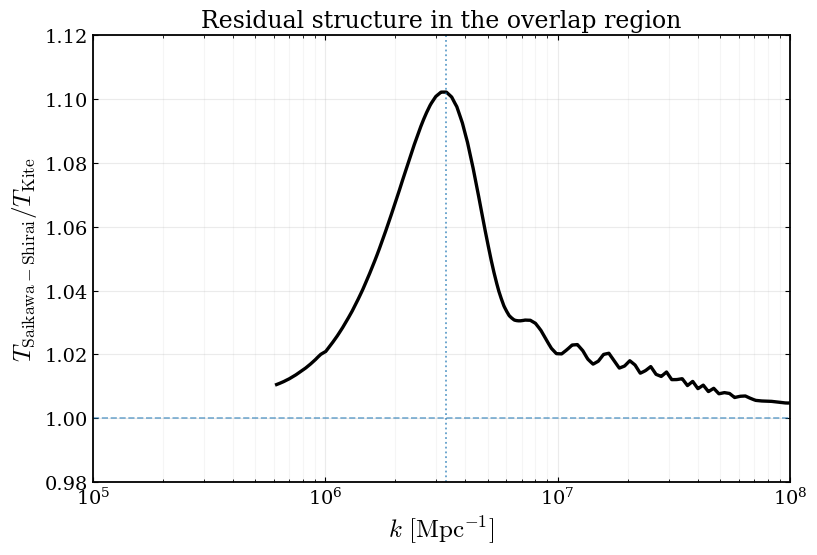

In [25]:
fig, ax = plt.subplots(figsize=(9, 5.8))

ax.semilogx(
    k_overlap,
    ratio_SS_Kite,
    color="black",
    lw=2.4,
)

ax.axhline(
    1.0,
    ls="--",
    lw=1.2,
    alpha=0.6,
)

ax.axvline(
    k_overlap[i_max],
    ls=":",
    lw=1.3,
    alpha=0.7,
)

ax.set_xlim(1e5, 1e8)
ax.set_ylim(0.98, 1.12)

ax.set_xlabel(r"$k\ [{\rm Mpc}^{-1}]$")
ax.set_ylabel(
    r"$T_{\rm Saikawa-Shirai}/T_{\rm Kite}$"
)

ax.set_title(
    r"Residual structure in the overlap region"
)

ax.grid(True, which="major", alpha=0.25)
ax.grid(True, which="minor", alpha=0.12)

plt.show()

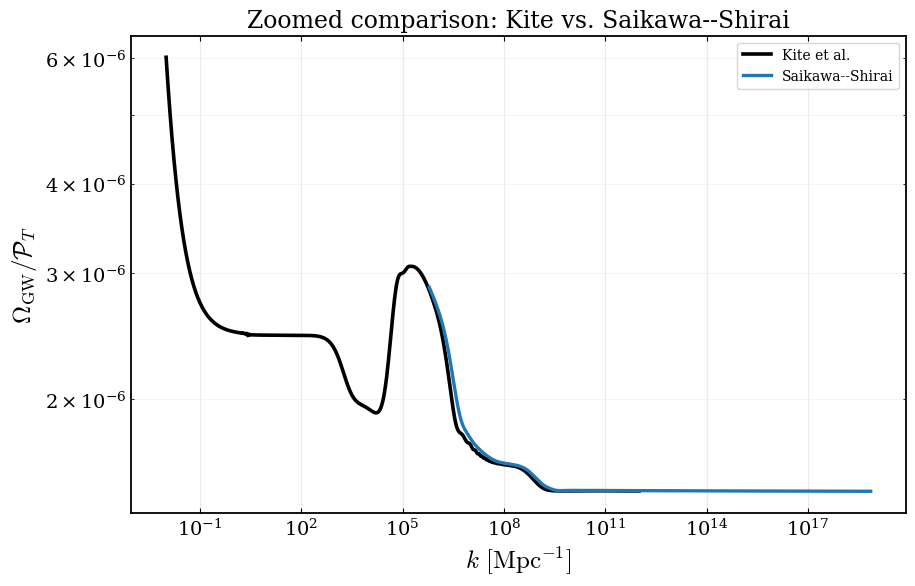

In [27]:
# ---------------------------------------------------------
# Overlay in the same convention:
# Omega_GW / P_T
# ---------------------------------------------------------

h_compare = 0.675
T_shirai_noh2 = tf_median / h_compare**2

fig, ax = plt.subplots(figsize=(10, 6.2))

ax.loglog(
    k_kite_full,
    Tomega_kite_full,
    color="black",
    lw=2.6,
    label=r"Kite et al."
)

ax.loglog(
    tf_k_invMpc,
    T_shirai_noh2,
    lw=2.4,
    label=r"Saikawa--Shirai"
)

# Zoom to the interesting region
# ax.set_xlim(1e5, 1e9)

ax.set_xlabel(r"$k\ [{\rm Mpc}^{-1}]$")
ax.set_ylabel(r"$\Omega_{\rm GW}/\mathcal{P}_T$")

ax.set_title(
    r"Zoomed comparison: Kite vs. Saikawa--Shirai"
)

ax.grid(True, which="major", alpha=0.25)
ax.grid(True, which="minor", alpha=0.12)

ax.legend()

plt.show()

In [28]:
sample_ks = np.array([
    1e6,
    3e6,
    1e7,
    1e8,
    1e9,
    1e10,
    1e11,
])

# interpolate both onto these k values
kite_sample = np.exp(
    np.interp(
        np.log(sample_ks),
        np.log(k_kite_full),
        np.log(Tomega_kite_full)
    )
)

shirai_sample = np.exp(
    np.interp(
        np.log(sample_ks),
        np.log(tf_k_invMpc),
        np.log(T_shirai_noh2)
    )
)

ratio_sample = shirai_sample / kite_sample

print(
    f"{'k [Mpc^-1]':>15} "
    f"{'Kite':>15} "
    f"{'Shirai':>15} "
    f"{'SS/Kite':>12}"
)

for k, tk, ts, r in zip(
    sample_ks,
    kite_sample,
    shirai_sample,
    ratio_sample
):
    print(
        f"{k:15.3e} "
        f"{tk:15.6e} "
        f"{ts:15.6e} "
        f"{r:12.5f}"
    )

     k [Mpc^-1]            Kite          Shirai      SS/Kite
      1.000e+06    2.653004e-06    2.708269e-06      1.02083
      3.000e+06    1.964621e-06    2.162960e-06      1.10096
      1.000e+07    1.729930e-06    1.764875e-06      1.02020
      1.000e+08    1.620071e-06    1.627819e-06      1.00478
      1.000e+09    1.522174e-06    1.542153e-06      1.01313
      1.000e+10    1.488671e-06    1.490945e-06      1.00153
      1.000e+11    1.489148e-06    1.490307e-06      1.00078


Get tha merged transfer function

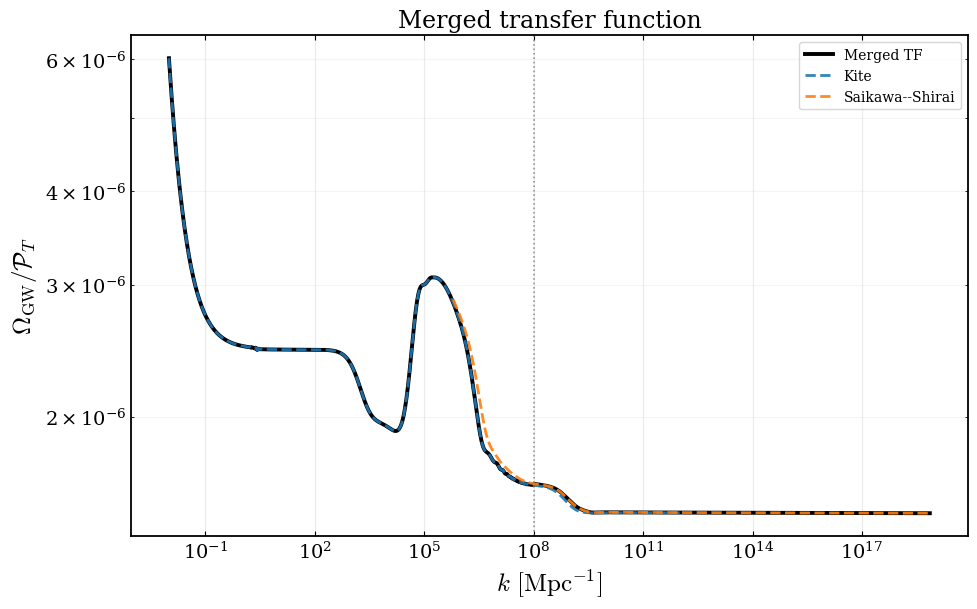

Switch scale:
k_switch = 100000000.0

Values at the switch:
Kite   = 1.6200705839263604e-06
Shirai = 1.6278186730087464e-06
ratio  = 1.0047825626607008


In [29]:
# ============================================================
# MERGED TRANSFER FUNCTION
# convention: Omega_GW / P_T
# ============================================================

from scipy.interpolate import interp1d
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Put Shirai into same convention as Kite
# ------------------------------------------------------------

h_compare = 0.675
T_shirai_noh2 = tf_median / h_compare**2


# ------------------------------------------------------------
# 2. Interpolators in log-log space
# ------------------------------------------------------------

kite_interp = interp1d(
    np.log(k_kite_full),
    np.log(Tomega_kite_full),
    kind="linear",
    bounds_error=False,
    fill_value=np.nan,
)

shirai_interp = interp1d(
    np.log(tf_k_invMpc),
    np.log(T_shirai_noh2),
    kind="linear",
    bounds_error=False,
    fill_value=np.nan,
)


# ------------------------------------------------------------
# 3. Build common k grid
# ------------------------------------------------------------

k_min = np.min(k_kite_full)
k_max = max(np.max(k_kite_full), np.max(tf_k_invMpc))

k_merged = np.logspace(
    np.log10(k_min),
    np.log10(k_max),
    2000
)

T_kite_grid = np.exp(kite_interp(np.log(k_merged)))
T_shirai_grid = np.exp(shirai_interp(np.log(k_merged)))


# ------------------------------------------------------------
# 4. Hard splice
#    Use Kite below k_switch, Shirai above
# ------------------------------------------------------------

k_switch = 1e8

T_merged = np.where(
    k_merged < k_switch,
    T_kite_grid,
    T_shirai_grid
)


# ------------------------------------------------------------
# 5. Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10.8, 6.5))

# merged TF
ax.loglog(
    k_merged,
    T_merged,
    color="black",
    lw=2.8,
    label=r"Merged TF"
)

# original Kite
ax.loglog(
    k_kite_full,
    Tomega_kite_full,
    ls="--",
    lw=2.0,
    alpha=0.9,
    label=r"Kite"
)

# original Shirai
ax.loglog(
    tf_k_invMpc,
    T_shirai_noh2,
    ls="--",
    lw=2.0,
    alpha=0.9,
    label=r"Saikawa--Shirai"
)

ax.axvline(
    k_switch,
    color="gray",
    ls=":",
    lw=1.2,
    alpha=0.8,
)

ax.set_xlabel(r"$k\ [{\rm Mpc}^{-1}]$")
ax.set_ylabel(r"$\Omega_{\rm GW}/\mathcal{P}_T$")
ax.set_title(r"Merged transfer function")

ax.grid(True, which="major", alpha=0.25)
ax.grid(True, which="minor", alpha=0.12)

ax.legend()

plt.show()


# ------------------------------------------------------------
# 6. Print the values at the switch
# ------------------------------------------------------------

T_kite_switch = np.exp(kite_interp(np.log(k_switch)))
T_shirai_switch = np.exp(shirai_interp(np.log(k_switch)))

print("Switch scale:")
print("k_switch =", k_switch)

print("\nValues at the switch:")
print("Kite   =", T_kite_switch)
print("Shirai =", T_shirai_switch)
print("ratio  =", T_shirai_switch / T_kite_switch)

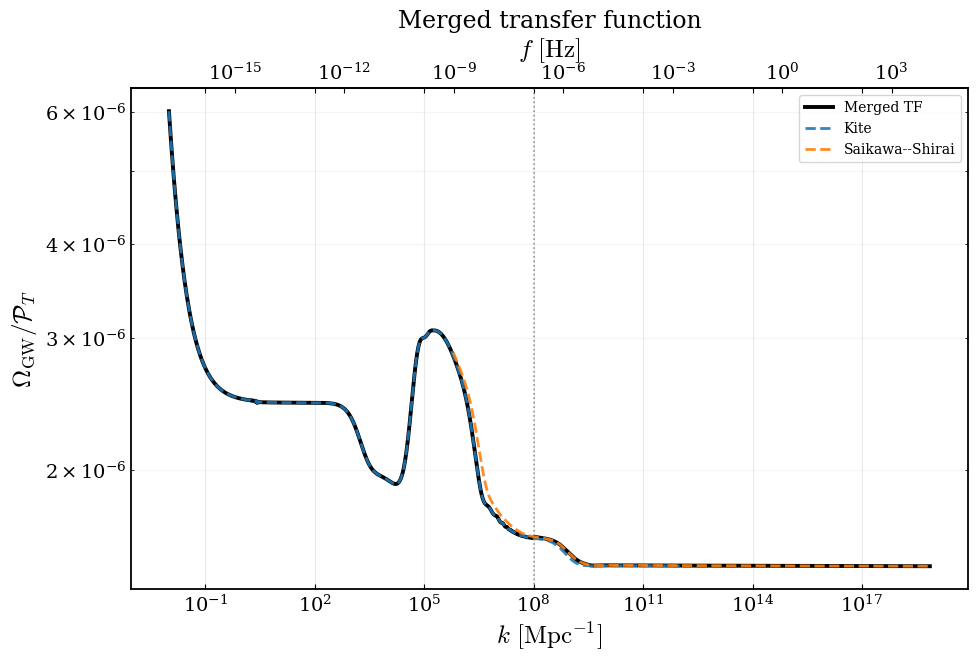

In [30]:
# ------------------------------------------------------------
# 5. Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10.8, 6.5))

ax.loglog(
    k_merged,
    T_merged,
    color="black",
    lw=2.8,
    label=r"Merged TF"
)

ax.loglog(
    k_kite_full,
    Tomega_kite_full,
    ls="--",
    lw=2.0,
    alpha=0.9,
    label=r"Kite"
)

ax.loglog(
    tf_k_invMpc,
    T_shirai_noh2,
    ls="--",
    lw=2.0,
    alpha=0.9,
    label=r"Saikawa--Shirai"
)

ax.axvline(
    k_switch,
    color="gray",
    ls=":",
    lw=1.2,
    alpha=0.8,
)

ax.set_xlabel(r"$k\ [{\rm Mpc}^{-1}]$")
ax.set_ylabel(r"$\Omega_{\rm GW}/\mathcal{P}_T$")
ax.set_title(r"Merged transfer function")

ax.grid(True, which="major", alpha=0.25)
ax.grid(True, which="minor", alpha=0.12)

ax.legend()


# ------------------------------------------------------------
# Frequency axis
# ------------------------------------------------------------

c_si = 299792458.0
Mpc_m = 3.085677581e22

def k_Mpc_to_f_Hz(k_Mpc):
    return c_si * np.asarray(k_Mpc) / (2.0 * np.pi * Mpc_m)

def f_Hz_to_k_Mpc(f_Hz):
    return 2.0 * np.pi * np.asarray(f_Hz) * Mpc_m / c_si


secax = ax.secondary_xaxis(
    "top",
    functions=(k_Mpc_to_f_Hz, f_Hz_to_k_Mpc),
)

secax.set_xscale("log")
secax.set_xlabel(r"$f\ [{\rm Hz}]$")


plt.show()

Full function:

In [15]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from scipy.interpolate import interp1d


def build_merged_gw_transfer_function(
    shirai_dir,
    kite_dir,
    output_dir,
    h=0.675,
    k_switch=1.0e8,
    n_grid=5000,
    save_plot=True,
    show_plot=True,
):
    """
    Build a merged present-day GW transfer function using

        Kite et al.            -> low/intermediate k
        Saikawa & Shirai       -> high k

    Final convention:
        T_Omega(k) = Omega_GW,0(k) / P_T(k)

    Parameters
    ----------
    shirai_dir : str or pathlib.Path
        Directory containing:
            k_file_tf.dat
            f_file_tf.dat
            Tf_median.dat

    kite_dir : str or pathlib.Path
        Kite 'data_availability' directory containing:
            GW.gstar_full.dat
            large_k_spectra/GW.GW_today_standard_env.dat

    output_dir : str or pathlib.Path
        Directory where the merged transfer function and plot
        will be saved.

    h : float, default=0.675
        Reduced Hubble constant used to put Shirai and Kite into
        the same Omega_GW / P_T convention.

    k_switch : float, default=1e8
        Switching scale [Mpc^-1].
        Kite is used below this scale and Shirai above it.

    n_grid : int, default=5000
        Number of logarithmically spaced points in the final
        merged transfer function.

    save_plot : bool
        Save the comparison figure.

    show_plot : bool
        Display the comparison figure.

    Returns
    -------
    results : dict
        Dictionary containing the merged transfer function and
        useful intermediate arrays.
    """

    # ============================================================
    # Paths
    # ============================================================

    shirai_dir = Path(shirai_dir)
    kite_dir = Path(kite_dir)
    output_dir = Path(output_dir)

    output_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    # ------------------------------------------------------------
    # Required files
    # ------------------------------------------------------------

    shirai_k_file = shirai_dir / "k_file_tf.dat"
    shirai_f_file = shirai_dir / "f_file_tf.dat"
    shirai_T_file = shirai_dir / "Tf_median.dat"

    kite_env_file = (
        kite_dir
        / "large_k_spectra"
        / "GW.GW_today_standard_env.dat"
    )

    kite_gstar_file = (
        kite_dir
        / "GW.gstar_full.dat"
    )

    required_files = [
        shirai_k_file,
        shirai_f_file,
        shirai_T_file,
        kite_env_file,
        kite_gstar_file,
    ]

    for filename in required_files:
        if not filename.exists():
            raise FileNotFoundError(
                f"Required file not found:\n{filename}"
            )

    # ============================================================
    # Constants
    # ============================================================

    c_si = 299792458.0
    c_km_s = 299792.458
    Mpc_m = 3.085677581e22

    # H0 in Mpc^-1
    H0_Mpc_inv = (
        100.0 * h / c_km_s
    )

    # ============================================================
    # Conversion functions
    # ============================================================

    def k_Mpc_to_f_Hz(k_Mpc):
        """
        k [Mpc^-1] -> f [Hz]
        """
        return (
            c_si
            * np.asarray(k_Mpc)
            / (2.0 * np.pi * Mpc_m)
        )

    def f_Hz_to_k_Mpc(f_Hz):
        """
        f [Hz] -> k [Mpc^-1]
        """
        return (
            2.0
            * np.pi
            * np.asarray(f_Hz)
            * Mpc_m
            / c_si
        )

    # ============================================================
    # 1. Load Saikawa-Shirai
    # ============================================================

    tf_k_input = np.loadtxt(
        shirai_k_file
    )

    tf_f = np.loadtxt(
        shirai_f_file
    )

    tf_median = np.loadtxt(
        shirai_T_file
    )

    if not (
        len(tf_k_input)
        == len(tf_f)
        == len(tf_median)
    ):
        raise ValueError(
            "The three Shirai arrays do not have the same length."
        )

    # Convert Shirai frequency to k [Mpc^-1]
    k_shirai = f_Hz_to_k_Mpc(
        tf_f
    )

    # Shirai table convention:
    #
    #     h^2 Omega_GW / P_T
    #
    # Convert to:
    #
    #     Omega_GW / P_T
    #
    T_shirai = (
        tf_median / h**2
    )

    # Sort just in case
    order = np.argsort(
        k_shirai
    )

    k_shirai = k_shirai[order]
    T_shirai = T_shirai[order]

    # ============================================================
    # 2. Load Kite numerical envelope
    # ============================================================

    kite_env = np.loadtxt(
        kite_env_file
    )

    k_env = kite_env[:, 0]

    # Columns:
    #
    # 0 : k
    # 1 : h envelope free
    # 2 : h' envelope free
    # 3 : h envelope damped
    # 4 : h' envelope damped

    hp_free_env = kite_env[:, 2]
    hp_damp_env = kite_env[:, 4]

    # ============================================================
    # 3. Convert Kite envelope to Omega_GW / P_T
    # ============================================================

    # Envelope amplitude squared must be oscillation averaged:
    #
    #     <cos^2> = 1/2
    #
    # Therefore:
    #
    # Omega_GW / P_T
    #     = h'_env^2 / (24 H0^2)

    T_kite_free_env = (
        hp_free_env**2
        / (
            24.0
            * H0_Mpc_inv**2
        )
    )

    T_kite_damp_env = (
        hp_damp_env**2
        / (
            24.0
            * H0_Mpc_inv**2
        )
    )

    # ============================================================
    # 4. Load Kite high-k g* table
    # ============================================================

    gstar = np.loadtxt(
        kite_gstar_file
    )

    k_high = gstar[:, 0]

    # Columns:
    #
    # 0 : k
    # 1 : g* on, free
    # 2 : g* on, damped
    # 3 : g* off, free
    # 4 : g* off, damped
    #
    # Full energy-density correction:
    #
    #       (g* on + damped)
    #       ----------------
    #       (g* off + free)

    C_full = (
        gstar[:, 2]
        / gstar[:, 3]
    )**2

    # Normalize the correction at k = 3 Mpc^-1.
    #
    # This attaches the correction smoothly to the numerical
    # Kite envelope.

    C_full_norm = (
        C_full / C_full[0]
    )

    T_kite_high = (
        T_kite_damp_env[-1]
        * C_full_norm
    )

    # ============================================================
    # 5. Full Kite curve
    # ============================================================

    # Skip the first high-k point because k=3 already exists
    # in the numerical envelope.

    k_kite_full = np.concatenate(
        [
            k_env,
            k_high[1:],
        ]
    )

    T_kite_full = np.concatenate(
        [
            T_kite_damp_env,
            T_kite_high[1:],
        ]
    )

    # ============================================================
    # 6. Validate switch point
    # ============================================================

    if not (
        k_kite_full.min()
        <= k_switch
        <= k_kite_full.max()
    ):
        raise ValueError(
            "k_switch is outside the Kite range."
        )

    if not (
        k_shirai.min()
        <= k_switch
        <= k_shirai.max()
    ):
        raise ValueError(
            "k_switch is outside the Shirai range."
        )

    # ============================================================
    # 7. Log-log interpolators
    # ============================================================

    kite_interp = interp1d(
        np.log(k_kite_full),
        np.log(T_kite_full),
        kind="linear",
        bounds_error=False,
        fill_value=np.nan,
    )

    shirai_interp = interp1d(
        np.log(k_shirai),
        np.log(T_shirai),
        kind="linear",
        bounds_error=False,
        fill_value=np.nan,
    )

    # ============================================================
    # 8. Build final merged k-grid
    # ============================================================

    # Low-k boundary comes from Kite.
    #
    # High-k boundary comes from Shirai because Shirai is used
    # after k_switch.

    k_min = k_kite_full.min()
    k_max = k_shirai.max()

    k_merged = np.logspace(
        np.log10(k_min),
        np.log10(k_max),
        n_grid,
    )

    T_merged = np.full(
        k_merged.shape,
        np.nan,
        dtype=float,
    )

    low_mask = (
        k_merged < k_switch
    )

    high_mask = (
        ~low_mask
    )

    # Kite branch
    T_merged[low_mask] = np.exp(
        kite_interp(
            np.log(
                k_merged[low_mask]
            )
        )
    )

    # Shirai branch
    T_merged[high_mask] = np.exp(
        shirai_interp(
            np.log(
                k_merged[high_mask]
            )
        )
    )

    # Frequency corresponding to merged k-grid
    f_merged = k_Mpc_to_f_Hz(
        k_merged
    )

    # ============================================================
    # 9. Switch diagnostics
    # ============================================================

    T_kite_switch = float(
        np.exp(
            kite_interp(
                np.log(k_switch)
            )
        )
    )

    T_shirai_switch = float(
        np.exp(
            shirai_interp(
                np.log(k_switch)
            )
        )
    )

    switch_ratio = (
        T_shirai_switch
        / T_kite_switch
    )

    # ============================================================
    # 10. Save final merged transfer function
    # ============================================================

    dat_file = (
        output_dir
        / "merged_gw_transfer_function.dat"
    )

    output_data = np.column_stack(
        [
            k_merged,
            f_merged,
            T_merged,
        ]
    )

    np.savetxt(
        dat_file,
        output_data,
        fmt="%.16e",
        header=(
            "Merged GW transfer function\n"
            "Convention: T_Omega(k) = Omega_GW,0 / P_T\n"
            f"h used for convention conversion = {h}\n"
            f"Kite used below k = {k_switch:.8e} Mpc^-1\n"
            f"Saikawa-Shirai used above k = {k_switch:.8e} Mpc^-1\n"
            "\n"
            "Columns:\n"
            "1: k [Mpc^-1]\n"
            "2: f [Hz]\n"
            "3: Omega_GW / P_T"
        ),
    )

    # ============================================================
    # 11. Save complete intermediate data
    # ============================================================

    npz_file = (
        output_dir
        / "merged_gw_transfer_function.npz"
    )

    np.savez(
        npz_file,

        # final
        k=k_merged,
        f=f_merged,
        T=T_merged,

        # Kite
        k_kite=k_kite_full,
        T_kite=T_kite_full,

        # Shirai
        k_shirai=k_shirai,
        T_shirai=T_shirai,

        # high-k correction
        k_gstar=k_high,
        C_full=C_full,
        C_full_normalized=C_full_norm,

        # metadata
        h=h,
        H0_Mpc_inv=H0_Mpc_inv,
        k_switch=k_switch,
        switch_ratio=switch_ratio,
    )

    # ============================================================
    # 12. Plot
    # ============================================================

    fig, ax = plt.subplots(
        figsize=(11.0, 6.7)
    )

    # Final merged TF
    ax.loglog(
        k_merged,
        T_merged,
        color="black",
        ls="--",
        lw=2.8,
        label=r"Merged TF",
        zorder=5,
    )

    # Kite
    ax.loglog(
        k_kite_full,
        T_kite_full,
        ls="--",
        lw=1.9,
        alpha=0.85,
        label=r"Kite et al.",
    )

    # Shirai
    ax.loglog(
        k_shirai,
        T_shirai,
        ls="--",
        lw=1.9,
        alpha=0.85,
        label=r"Saikawa--Shirai",
    )

    # Switch
    ax.axvline(
        k_switch,
        color="gray",
        ls=":",
        lw=1.2,
        alpha=0.75,
    )

    ax.set_xlabel(
        r"$k\ [{\rm Mpc}^{-1}]$"
    )

    ax.set_ylabel(
        r"$\Omega_{\rm GW}/\mathcal{P}_T$"
    )

    ax.set_title(
        r"Merged primordial-GW transfer function"
    )

    ax.grid(
        True,
        which="major",
        alpha=0.25,
    )

    ax.grid(
        True,
        which="minor",
        alpha=0.12,
    )

    ax.legend()

    # ------------------------------------------------------------
    # Frequency axis
    # ------------------------------------------------------------

    secax = ax.secondary_xaxis(
        "top",
        functions=(
            k_Mpc_to_f_Hz,
            f_Hz_to_k_Mpc,
        ),
    )

    secax.set_xscale("log")

    secax.set_xlabel(
        r"$f\ [{\rm Hz}]$"
    )

    fig.tight_layout()

    # ============================================================
    # 13. Save figure
    # ============================================================

    figure_file = (
        output_dir
        / "merged_gw_transfer_function.png"
    )

    if save_plot:
        fig.savefig(
            figure_file,
            dpi=300,
            bbox_inches="tight",
        )

    if show_plot:
        plt.show()
    else:
        plt.close(fig)

    # ============================================================
    # 14. Diagnostics
    # ============================================================

    print("\n==========================================")
    print("Merged GW transfer function")
    print("==========================================")

    print(
        f"Kite range:"
        f"   {k_kite_full.min():.6e}"
        f" -> {k_kite_full.max():.6e} Mpc^-1"
    )

    print(
        f"Shirai range:"
        f" {k_shirai.min():.6e}"
        f" -> {k_shirai.max():.6e} Mpc^-1"
    )

    print(
        f"Merged range:"
        f" {k_merged.min():.6e}"
        f" -> {k_merged.max():.6e} Mpc^-1"
    )

    print(
        f"\nk_switch = {k_switch:.6e} Mpc^-1"
    )

    print(
        f"Kite at switch   = "
        f"{T_kite_switch:.8e}"
    )

    print(
        f"Shirai at switch = "
        f"{T_shirai_switch:.8e}"
    )

    print(
        f"Shirai / Kite    = "
        f"{switch_ratio:.8f}"
    )

    print("\nSaved:")
    print(dat_file)
#     print(npz_file)

    if save_plot:
        print(figure_file)

    print("==========================================\n")

    # ============================================================
    # Return everything useful
    # ============================================================

    return {
        "k": k_merged,
        "f": f_merged,
        "T": T_merged,

        "k_kite": k_kite_full,
        "T_kite": T_kite_full,

        "k_shirai": k_shirai,
        "T_shirai": T_shirai,

        "k_switch": k_switch,
        "switch_ratio": switch_ratio,

        "dat_file": dat_file,
#         "npz_file": npz_file,
        "figure_file": figure_file,
    }

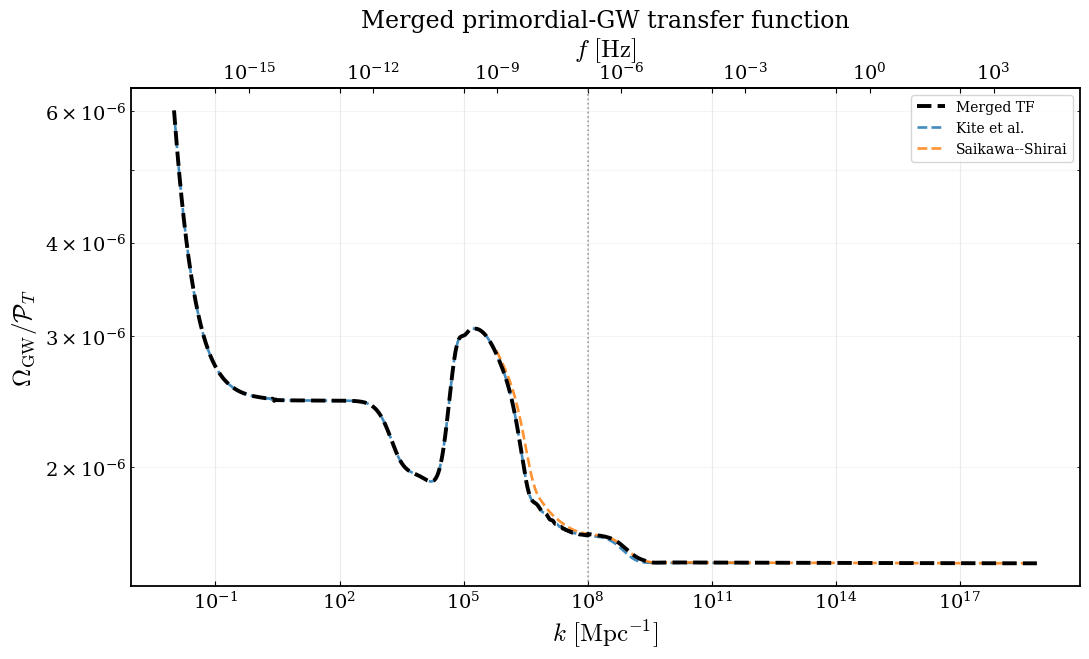


Merged GW transfer function
Kite range:   1.000000e-02 -> 1.000000e+12 Mpc^-1
Shirai range: 6.175630e+05 -> 7.178160e+18 Mpc^-1
Merged range: 1.000000e-02 -> 7.178160e+18 Mpc^-1

k_switch = 1.000000e+08 Mpc^-1
Kite at switch   = 1.62007058e-06
Shirai at switch = 1.62781867e-06
Shirai / Kite    = 1.00478256

Saved:
/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/InflationModels/merged_transfer_function/merged_gw_transfer_function.dat
/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/InflationModels/merged_transfer_function/merged_gw_transfer_function.png



In [16]:
from pathlib import Path

base_path_tf = Path(
    "/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/"
    "inflation_code/Slow-Roll Parameters Tests"
)

base_path_kite = Path(
    "/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/"
    "inflation_code/InflationModels/data_availability"
)

output_dir = Path(
    "/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/"
    "inflation_code/InflationModels/merged_transfer_function"
)


tf = build_merged_gw_transfer_function(
    shirai_dir=base_path_tf,
    kite_dir=base_path_kite,
    output_dir=output_dir,
    h=0.675,
    k_switch=1e8,
)

Other inspection of files:

noneff: free == damp ? True


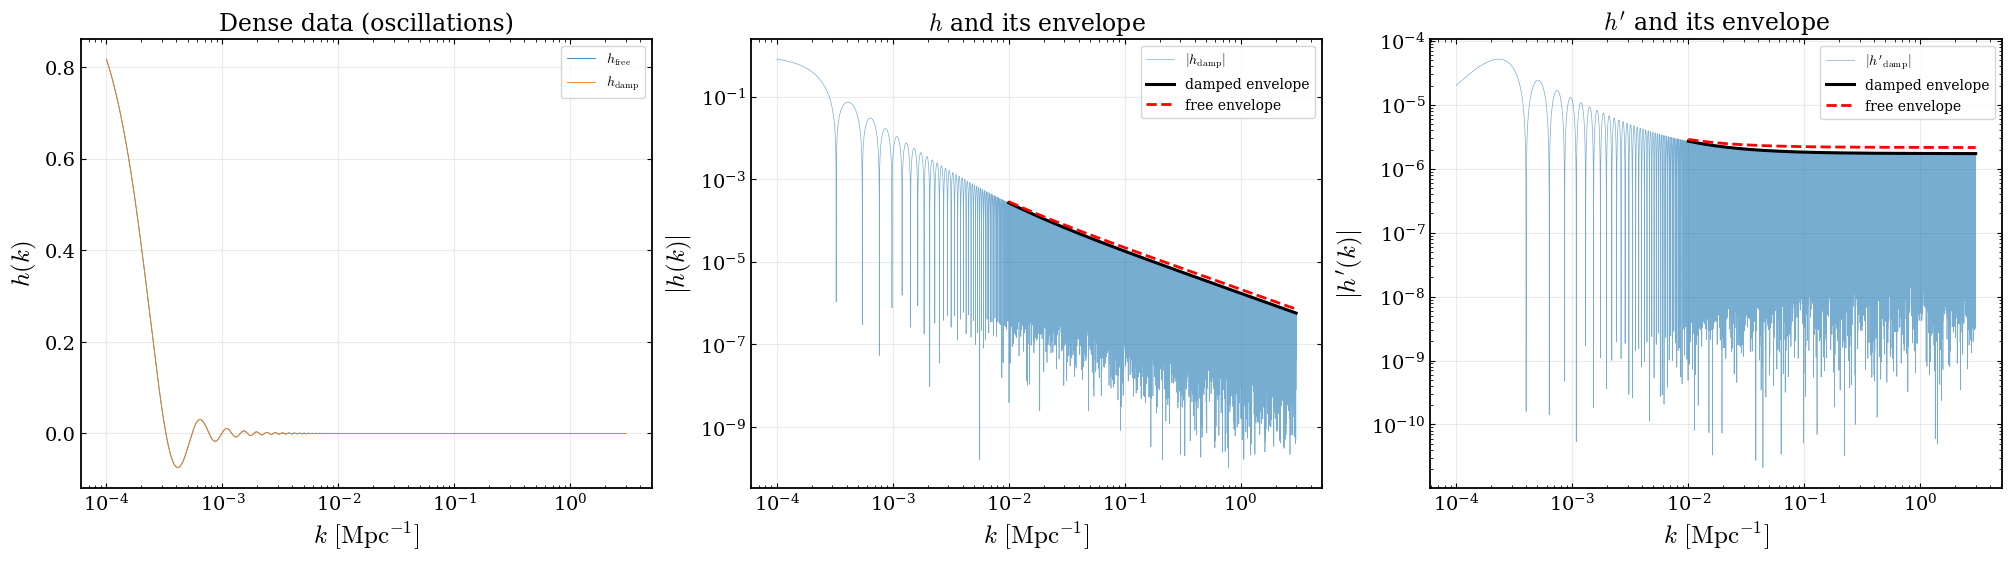

In [12]:
kite_large = base_path_kite / "large_k_spectra"

# columns: 0=k, 1=h_free, 2=h'_free, 3=h_damp, 4=h'_damp
std   = np.genfromtxt(kite_large / "GW.GW_today_standard.dat",     comments="#")
std_e = np.genfromtxt(kite_large / "GW.GW_today_standard_env.dat", comments="#")
nonef = np.genfromtxt(kite_large / "GW.GW_today_noneff.dat",       comments="#")

# Check my guess that free == damp when N_eff = 0
print("noneff: free == damp ?", np.allclose(nonef[:, 1], nonef[:, 3]))

fig, axes = plt.subplots(1, 3, figsize=(20, 5.5), constrained_layout=True)

# (a) raw h(k): linear y so you can see oscillations and sign changes
ax = axes[0]
ax.semilogx(std[:, 0], std[:, 1], lw=0.6, label=r"$h_{\rm free}$")
ax.semilogx(std[:, 0], std[:, 3], lw=0.6, label=r"$h_{\rm damp}$")
ax.set_ylabel(r"$h(k)$")
ax.set_title("Dense data (oscillations)")

# (b) |h| on log-log with the envelope on top
ax = axes[1]
ax.loglog(std[:, 0], np.abs(std[:, 3]), lw=0.5, alpha=0.6, label=r"$|h_{\rm damp}|$")
ax.loglog(std_e[:, 0], std_e[:, 3], "k", lw=2.2, label="damped envelope")
ax.loglog(std_e[:, 0], std_e[:, 1], "r--", lw=2.0, label="free envelope")
ax.set_ylabel(r"$|h(k)|$")
ax.set_title(r"$h$ and its envelope")

# (c) same for h'
ax = axes[2]
ax.loglog(std[:, 0], np.abs(std[:, 4]), lw=0.5, alpha=0.6, label=r"$|h'_{\rm damp}|$")
ax.loglog(std_e[:, 0], std_e[:, 4], "k", lw=2.2, label="damped envelope")
ax.loglog(std_e[:, 0], std_e[:, 2], "r--", lw=2.0, label="free envelope")
ax.set_ylabel(r"$|h'(k)|$")
ax.set_title(r"$h'$ and its envelope")

for ax in axes:
    ax.set_xlabel(r"$k\ [{\rm Mpc}^{-1}]$")
    ax.grid(True, which="major", alpha=0.25)
    ax.legend(fontsize=10)

plt.savefig("kite_dense_tf.png", dpi=300, bbox_inches="tight")
plt.show()

gstar_full spans f = 4.64e-15 to 1.55e-03 Hz


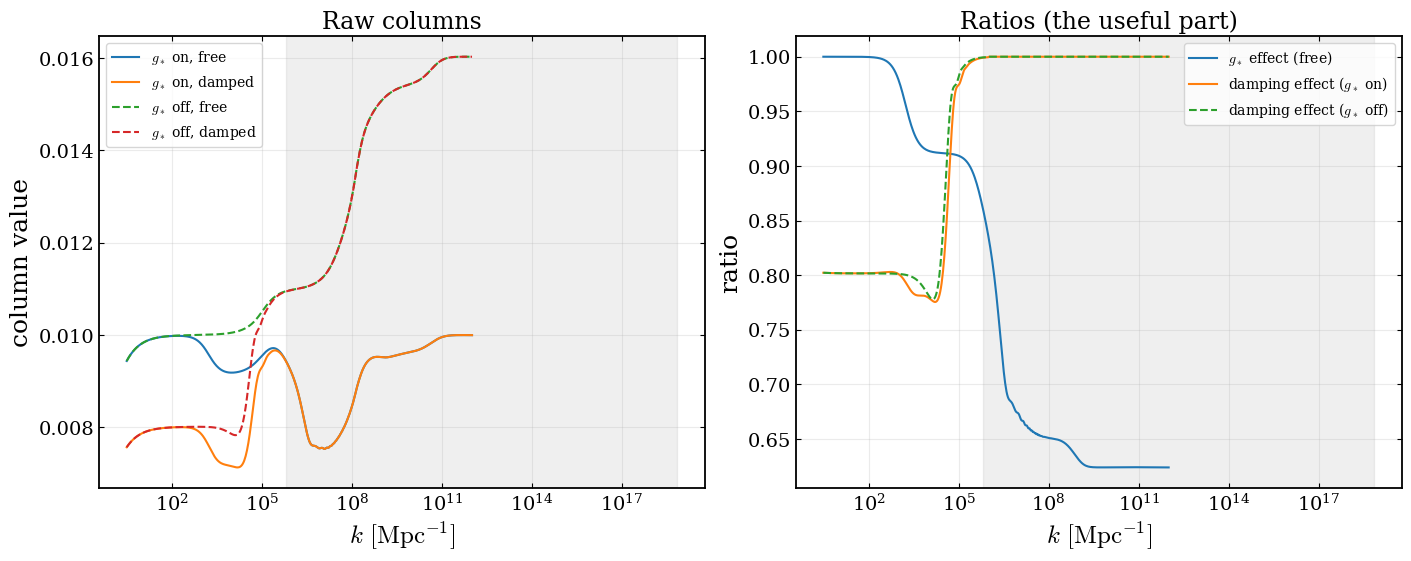

gstar_full at k_min: 3.0 0.007570794370915766
envelope at k = 3  : 2.999999999999968 5.76578261782393e-07


In [13]:
c_m_per_s = 299792458.0
Mpc_in_m  = 3.085677581e22

def k_Mpc_to_f_Hz(k):
    return k * c_m_per_s / (2.0 * np.pi * Mpc_in_m)

g = np.genfromtxt(base_path_kite / "GW.gstar_full.dat", comments="#")
k_g = g[:, 0]
on_free, on_damp, off_free, off_damp = g[:, 1], g[:, 2], g[:, 3], g[:, 4]

print(f"gstar_full spans f = {k_Mpc_to_f_Hz(k_g.min()):.2e} to {k_Mpc_to_f_Hz(k_g.max()):.2e} Hz")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), constrained_layout=True)

ax = axes[0]
ax.semilogx(k_g, on_free,  label=r"$g_*$ on, free")
ax.semilogx(k_g, on_damp,  label=r"$g_*$ on, damped")
ax.semilogx(k_g, off_free, "--", label=r"$g_*$ off, free")
ax.semilogx(k_g, off_damp, "--", label=r"$g_*$ off, damped")
ax.set_ylabel("column value")
ax.set_title("Raw columns")

ax = axes[1]
ax.semilogx(k_g, on_free / off_free,   label=r"$g_*$ effect (free)")
ax.semilogx(k_g, on_damp / on_free,    label=r"damping effect ($g_*$ on)")
ax.semilogx(k_g, off_damp / off_free,  "--", label=r"damping effect ($g_*$ off)")
ax.set_ylabel("ratio")
ax.set_title("Ratios (the useful part)")

for ax in axes:
    ax.set_xlabel(r"$k\ [{\rm Mpc}^{-1}]$")
    ax.grid(True, which="major", alpha=0.25)
    ax.legend(fontsize=10)
    # Shade where Shirai's data lives (uses tf_k_invMpc from your earlier script)
    ax.axvspan(tf_k_invMpc.min(), tf_k_invMpc.max(), color="gray", alpha=0.12)

plt.savefig("kite_gstar_full.png", dpi=300, bbox_inches="tight")
plt.show()

# Normalization check: compare to the dense/envelope data at k = 3 Mpc^-1
print("gstar_full at k_min:", k_g[0], on_damp[0])
print("envelope at k = 3  :", std_e[-1, 0], std_e[-1, 3])